# KMeans Classifier

The idea is to classify users in to clusters based on their movie preferences. The user will than have to select movies and rate them. Based on the ratings a classification will happen and movies which users in this class like watching will be recommended

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

In [2]:
# Load data from new location
ratings = pd.read_csv('../validation_dataset.csv')
movies = pd.read_csv('../dataFiles/movieData.csv')

# Check if validation dataset matches expected format
print("Validation dataset columns:", ratings.columns.tolist())
print("Validation dataset shape:", ratings.shape)
print("First few rows:")
print(ratings.head())

# Check if movies data matches expected format  
print("\nMovies dataset columns:", movies.columns.tolist())
print("Movies dataset shape:", movies.shape)
print("First few rows:")
print(movies.head())

# The validation dataset has the expected format: userId, movieId, rating, timestamp
# The movies dataset has additional columns but includes the core ones we need: movieId, title, genres

# Extract only the columns we need from movies to match original format
movies_original_format = movies[['movieId', 'title', 'genres']].copy()

# Verify we have the same structure as before
print("\nFiltered movies columns:", movies_original_format.columns.tolist())
print("Sample of filtered movies data:")
print(movies_original_format.head())

# Use the filtered movies data for the merge
movies = movies_original_format
ratings = pd.merge(ratings, movies, on='movieId', how='inner')

print(f"\nMerged dataset shape: {ratings.shape}")
print("Merged dataset columns:", ratings.columns.tolist())
print("Sample merged data:")
print(ratings.head())

Validation dataset columns: ['userId', 'movieId', 'rating', 'timestamp']
Validation dataset shape: (3808433, 4)
First few rows:
   userId  movieId  rating  timestamp
0       5        1     4.0  858625949
1       5       19     4.0  830786345
2       5       32     5.0  830786277
3       5       36     5.0  830786409
4       5       39     2.0  858627955

Movies dataset columns: ['movieId', 'title', 'genres', 'year', 'imdbId', 'tmdbId', 'count', 'avgRating', 'img', 'g_(no genres listed)', 'g_Action', 'g_Adventure', 'g_Animation', 'g_Children', 'g_Comedy', 'g_Crime', 'g_Documentary', 'g_Drama', 'g_Fantasy', 'g_Film-Noir', 'g_Horror', 'g_IMAX', 'g_Musical', 'g_Mystery', 'g_Romance', 'g_Sci-Fi', 'g_Thriller', 'g_War', 'g_Western', 'time_adjusted_rating']
Movies dataset shape: (62423, 30)
First few rows:
   movieId                        title  \
0        1                    Toy Story   
1        2                      Jumanji   
2        3             Grumpier Old Men   
3        4       

In [3]:
active_users = ratings.groupby('userId').size().reset_index(name='count')
active_users = active_users.sort_values(by='count', ascending=False)
active_users = active_users.head(5000)

In [4]:
popular_movies = ratings.groupby('movieId').size().reset_index(name='count')
popular_movies = popular_movies.sort_values(by='count', ascending=False)
popular_movies = popular_movies.head(10000)

In [5]:

ratings = ratings[ratings['userId'].isin(active_users['userId']) & ratings['movieId'].isin(popular_movies['movieId'])]


user_item_matrix = ratings.pivot_table(index='userId', columns='title', values='rating', fill_value=0)

In [6]:
user_item_matrix.iloc[:5,:5]

title,"""Great Performances"" Cats",'71,'Round Midnight,'Salem's Lot,'Til There Was You
userId,,,,,
38,0.0,0.0,0.0,0.0,0.0
57,0.0,0.0,0.0,0.0,0.0
62,0.0,0.0,0.0,0.0,0.0
75,0.0,0.0,0.0,0.0,0.0
95,0.0,0.0,0.0,0.0,0.0


In [7]:
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10, max_iter=300)
user_item_matrix['cluster'] = kmeans.fit_predict(user_item_matrix)


In [8]:
movie_columns = user_item_matrix.columns[1:-1]  # exclude userId and cluster

# Group by cluster and calculate mean rating per movie
cluster_movie_means = user_item_matrix.groupby('cluster')[movie_columns].mean()

# For each cluster, get top 10 movies
top_movies_per_cluster = {}

for cluster in cluster_movie_means.index:
	top_10 = cluster_movie_means.loc[cluster].sort_values(ascending=False).head(10)
	top_movies_per_cluster[cluster] = top_10
	print(f"Cluster {cluster} top movies:")
	print(top_10.index.tolist())

# Convert result to DataFrame for better display
result_df = pd.DataFrame.from_dict(top_movies_per_cluster, orient='index').transpose()
result_df.columns.name = 'Cluster'


Cluster 0 top movies:
['Fight Club', 'Pulp Fiction', 'The Matrix', 'The Shawshank Redemption', 'Forrest Gump', 'American Beauty', 'The Lord of the Rings: The Fellowship of the Ring', 'Inception', 'The Dark Knight', 'Eternal Sunshine of the Spotless Mind']
Cluster 1 top movies:
['The Godfather', 'Fargo', "Schindler's List", 'Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark)', 'American Beauty', 'Pulp Fiction', 'Star Wars: Episode IV - A New Hope', 'Jaws', 'The Shawshank Redemption', 'Chinatown']
Cluster 2 top movies:
['Pulp Fiction', 'Fight Club', 'The Matrix', 'The Shawshank Redemption', 'The Silence of the Lambs', 'Memento', 'Seven (a.k.a. Se7en)', 'The Dark Knight', 'Forrest Gump', 'The Lord of the Rings: The Fellowship of the Ring']
Cluster 3 top movies:
['The Matrix', 'The Shawshank Redemption', 'The Dark Knight', 'Fight Club', 'The Lord of the Rings: The Fellowship of the Ring', 'Inception', 'Pulp Fiction', 'The Lord of the Rings: The Return of the King', 'St

clusters created. Now looking for movies with best entropy splitting

In [9]:
import numpy as np
import pandas as pd

# Function to compute entropy from a value distribution
def entropy(probs):
    return -np.sum([p * np.log2(p) for p in probs if p > 0])

# Compute overall cluster entropy
cluster_probs = user_item_matrix['cluster'].value_counts(normalize=True)
overall_entropy = entropy(cluster_probs)

# Binning function for ratings
def bin_rating(r):
    if r == 0:
        return 'none'
    elif r < 2.5:
        return 'low'
    elif r < 3.5:
        return 'mid'
    else:
        return 'high'
    

# Store results
info_gains = []

# Remove 'cluster' column for iteration
matrix = user_item_matrix.drop(columns='cluster')
clusters = user_item_matrix['cluster']

for movie in matrix.columns:
    # Create a Series with binned ratings
    bins = matrix[movie].apply(bin_rating)

    bin_entropy = 0
    total = len(bins)

    for b in ['none', 'low', 'mid', 'high']:
        idx = bins[bins == b].index
        if len(idx) == 0:
            continue
        weight = len(idx) / total
        cluster_dist = clusters.loc[idx].value_counts(normalize=True)
        bin_entropy += weight * entropy(cluster_dist)

    info_gain = overall_entropy - bin_entropy
    info_gains.append((movie, info_gain))

In [10]:
# Sort descending by info gain
info_gains.sort(key=lambda x: x[1], reverse=True)

# Show top 10 - movie is already the title, not movieId
for movie, gain in info_gains[:10]:
    print(f"{movie:<50} Info Gain: {gain:.4f}")

Inception                                          Info Gain: 0.4929
The Dark Knight                                    Info Gain: 0.4615
Iron Man                                           Info Gain: 0.4112
Avatar                                             Info Gain: 0.3967
The Dark Knight Rises                              Info Gain: 0.3907
Guardians of the Galaxy                            Info Gain: 0.3813
Inglourious Basterds                               Info Gain: 0.3808
Interstellar                                       Info Gain: 0.3684
The Lord of the Rings: The Return of the King      Info Gain: 0.3618
Django Unchained                                   Info Gain: 0.3598


Sample movie columns available:
Total movies: 9683
First 10 movies: ['"Great Performances" Cats', "'71", "'Round Midnight", "'Salem's Lot", "'Til There Was You", "'night Mother", '(500) Days of Summer', '*batteries not included', '...And Justice for All', '10']
Last 10 movies: ['[REC]', '[REC]²', '[REC]³ 3 Génesis', 'eXistenZ', 'loudQUIETloud: A Film About the Pixies', 'xXx', 'xXx: Return of Xander Cage', 'xXx: State of the Union', '¡Three Amigos!', 'À nous la liberté (Freedom for Us)']

Found potential target movies: ['The Matrix', 'The Matrix Reloaded', 'The Matrix Revolutions', 'The Shawshank Redemption']

Using movies for plotting: 'The Matrix' and 'The Matrix Reloaded'


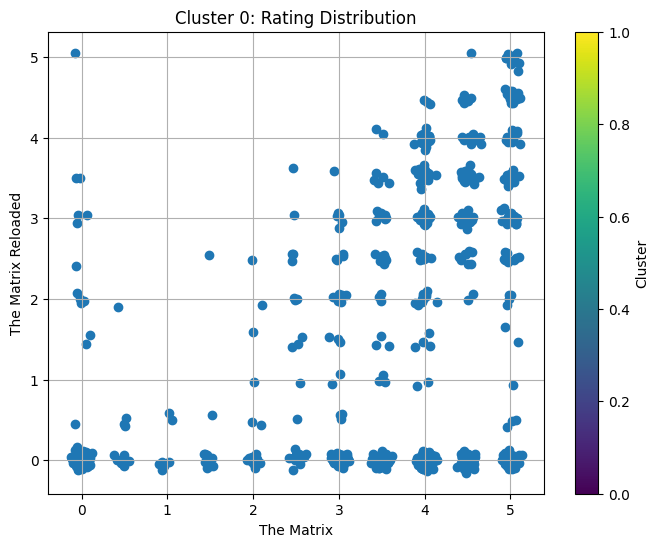

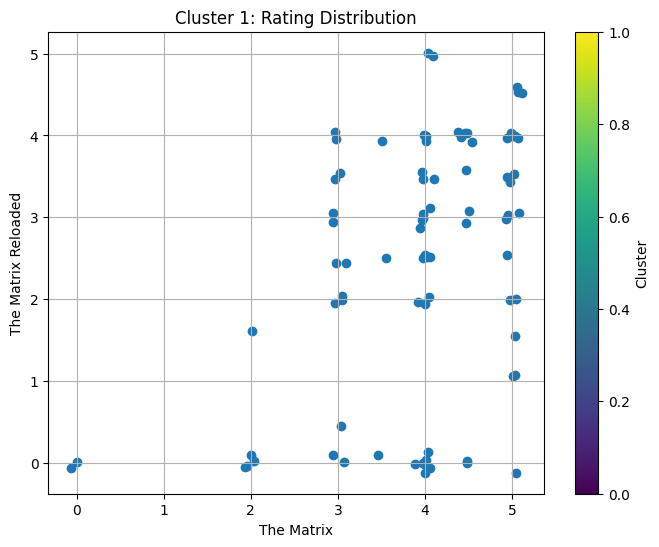

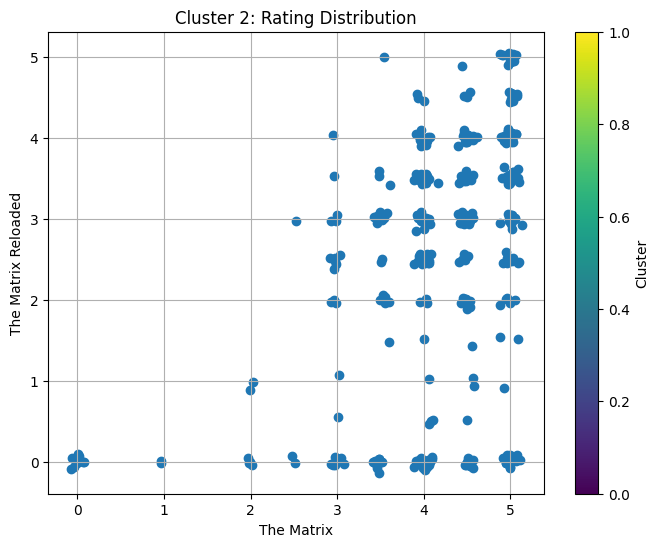

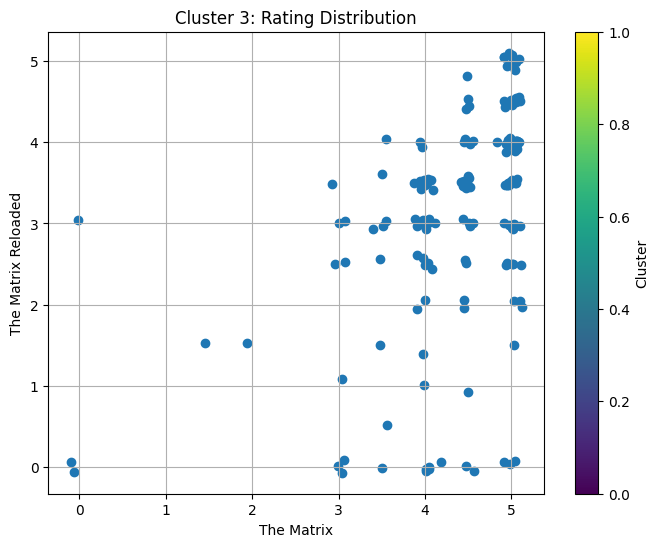

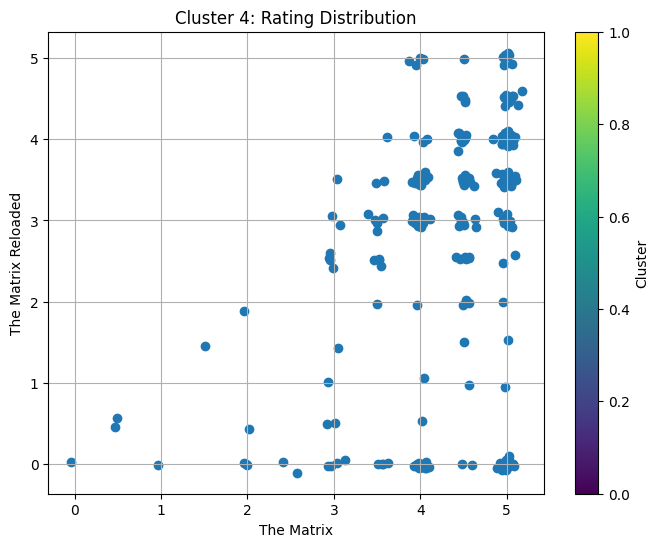

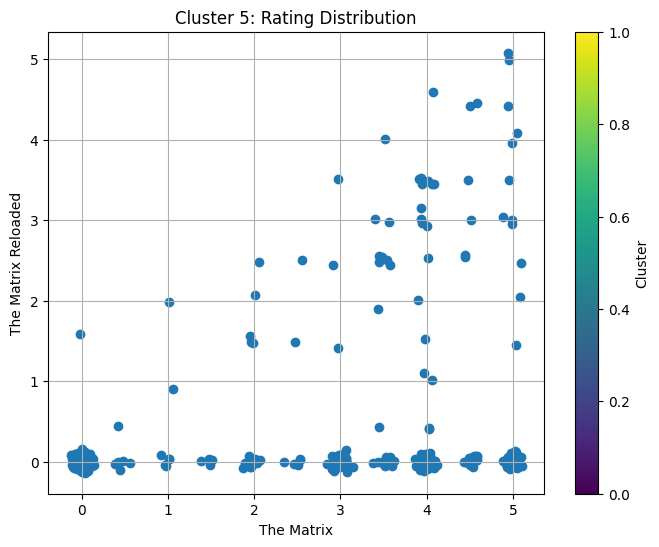

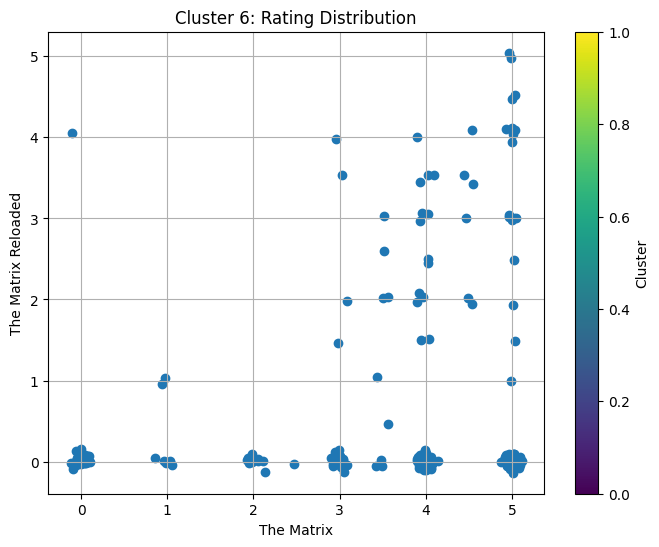

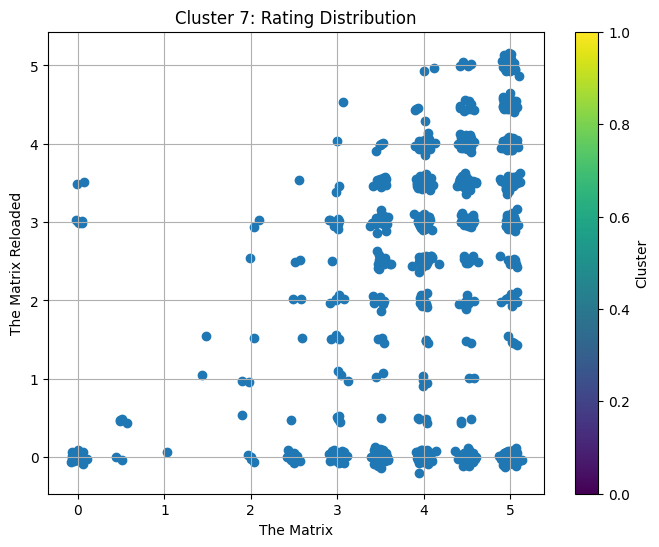

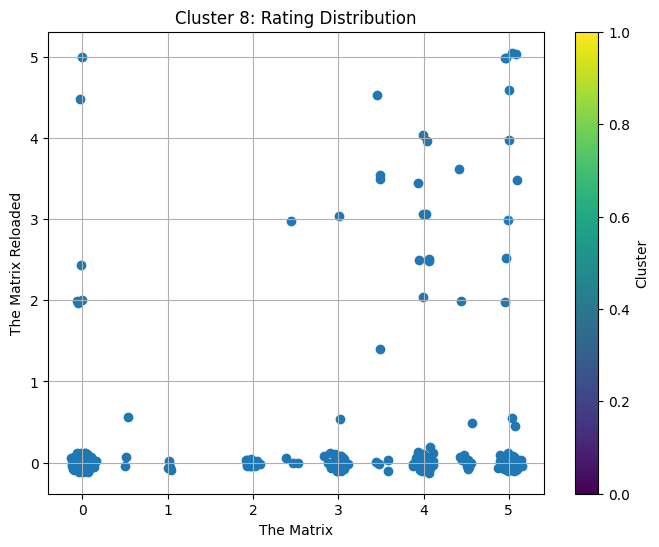

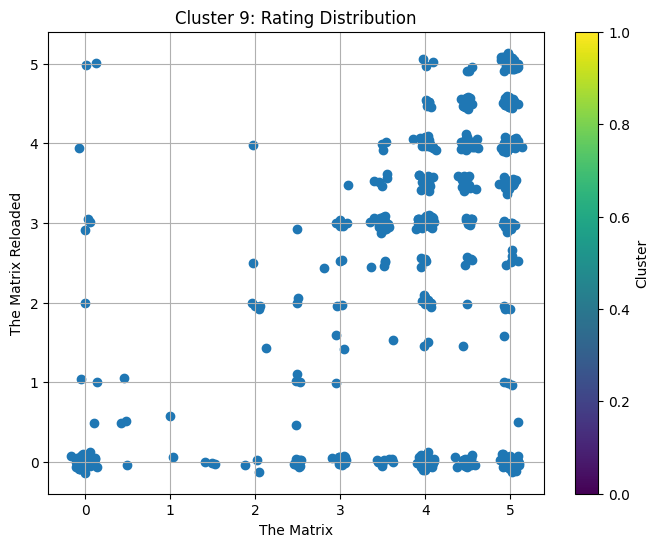

In [11]:
# Check available movie columns in the user_item_matrix
print("Sample movie columns available:")
movie_columns = [col for col in user_item_matrix.columns if col != 'cluster']
print(f"Total movies: {len(movie_columns)}")
print("First 10 movies:", movie_columns[:10])
print("Last 10 movies:", movie_columns[-10:])

# Find movies that might match our desired titles
target_movies = []
for col in movie_columns:
    if 'Shawshank' in col or 'Matrix' in col:
        target_movies.append(col)
        
print(f"\nFound potential target movies: {target_movies}")

# Use the first two available movies if our targets aren't found
if len(target_movies) >= 2:
    movie1, movie2 = target_movies[0], target_movies[1]
else:
    # Use first two movies with ratings > 0 in multiple clusters
    movie1 = movie_columns[0]
    movie2 = movie_columns[1]
    
print(f"\nUsing movies for plotting: '{movie1}' and '{movie2}'")

jitterX = np.random.normal(0, 0.05, size=user_item_matrix.shape[0])
jitterY = np.random.normal(0, 0.05, size=user_item_matrix.shape[0])

for i in range(10):
    scatterData = user_item_matrix[user_item_matrix["cluster"] == i].dropna(subset=[movie1, movie2])
    
    # Skip if no data for this cluster
    if len(scatterData) == 0:
        print(f"No data for cluster {i}")
        continue

    # Add jitter
    jitterX = np.random.normal(0, 0.05, size=scatterData.shape[0])
    jitterY = np.random.normal(0, 0.05, size=scatterData.shape[0])

    # Plot
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        scatterData[movie1] + jitterX,
        scatterData[movie2] + jitterY
            )
    plt.xlabel(movie1)
    plt.ylabel(movie2)
    plt.title(f'Cluster {i}: Rating Distribution')
    cbar = plt.colorbar(scatter)
    cbar.set_label('Cluster')
    plt.grid(True)
    plt.show()

### KNN Test

In [12]:
from tqdm import tqdm
import time

data = user_item_matrix.copy()
data = data.drop(columns=['cluster'])
knnData = data.copy()

results = []

# Total iterations for progress bar
total_iterations = len(range(2, 10)) * len(range(1, 21))
pbar = tqdm(total=total_iterations, desc="KMeans + KNN Evaluation")

best_results = {}  # Track best result per cluster count

for c in range(2, 10):
	cluster_results = []

	# Run KMeans once per cluster count
	kmeans = KMeans(n_clusters=c, random_state=42, n_init=10, max_iter=300)
	knnData['cluster'] = kmeans.fit_predict(data)

	X = knnData.drop(columns=['cluster'])
	y = knnData['cluster']
	X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

	for k in range(1, 21):
		knn = KNeighborsClassifier(n_neighbors=k)
		knn.fit(X_train, y_train)
		y_pred = knn.predict(X_test)

		acc = accuracy_score(y_test, y_pred)
		results.append({"clusters": c, "k": k, "acc": acc})
		cluster_results.append((k, acc))

		pbar.update(1)

	# Find best K for this cluster count
	best_k, best_acc = max(cluster_results, key=lambda x: x[1])
	best_results[c] = (best_k, best_acc)

	# Print summary for this cluster count
	print(f"Clusters: {c} | Best K: {best_k} | Best Accuracy: {best_acc:.4f}")

pbar.close()

# Overall summary
print("\n" + "="*50)
print("SUMMARY - Best Results by Cluster Count:")
print("="*50)
for clusters, (k, acc) in best_results.items():
	print(f"{clusters:2d} clusters | K={k:2d} | Accuracy: {acc:.4f}")

# Find overall best
overall_best = max(best_results.items(), key=lambda x: x[1][1])
print(f"\nOverall Best: {overall_best[0]} clusters, K={overall_best[1][0]}, Accuracy: {overall_best[1][1]:.4f}")




KMeans + KNN Evaluation:  12%|█▎        | 20/160 [00:19<01:32,  1.51it/s]

Clusters: 2 | Best K: 2 | Best Accuracy: 0.9030


KMeans + KNN Evaluation:  25%|██▌       | 40/160 [00:44<01:19,  1.50it/s]

Clusters: 3 | Best K: 10 | Best Accuracy: 0.8790


KMeans + KNN Evaluation:  38%|███▊      | 60/160 [01:12<01:07,  1.47it/s]

...

Clusters: 7 | Best K: 2 | Best Accuracy: 0.6820


KMeans + KNN Evaluation:  88%|████████▊ | 140/160 [03:26<00:13,  1.47it/s]

Clusters: 8 | Best K: 20 | Best Accuracy: 0.6620


KMeans + KNN Evaluation: 100%|██████████| 160/160 [04:03<00:00,  1.52s/it]

Clusters: 9 | Best K: 11 | Best Accuracy: 0.6200

SUMMARY - Best Results by Cluster Count:
 2 clusters | K= 2 | Accuracy: 0.9030
 3 clusters | K=10 | Accuracy: 0.8790
 4 clusters | K= 8 | Accuracy: 0.8050
 5 clusters | K= 9 | Accuracy: 0.7930
 6 clusters | K=15 | Accuracy: 0.7140
 7 clusters | K= 2 | Accuracy: 0.6820
 8 clusters | K=20 | Accuracy: 0.6620
 9 clusters | K=11 | Accuracy: 0.6200

Overall Best: 2 clusters, K=2, Accuracy: 0.9030


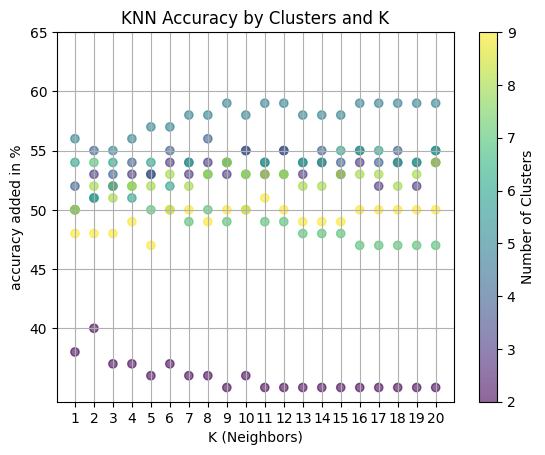

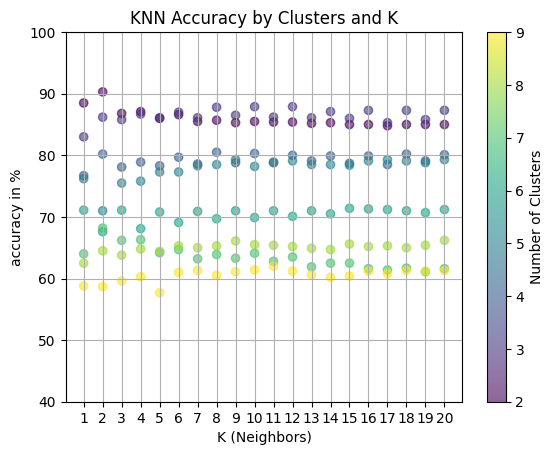

In [13]:
results_data = pd.DataFrame(results)
results_data["weightAcc"] =  results_data["acc"] - (1/results_data["clusters"])

plt.scatter(results_data['k'],results_data['weightAcc'].round(2)*100, c=results_data['clusters'], cmap='viridis', alpha=0.6)
plt.colorbar(label='Number of Clusters')
plt.xlabel('K (Neighbors)')
plt.ylabel('accuracy added in %')
plt.yticks(np.arange(40, 70, 5))
plt.xticks(np.arange(1, 21, 1))
plt.title('KNN Accuracy by Clusters and K')

plt.grid(True)
plt.show()

plt.scatter(results_data['k'],results_data['acc']*100, c=results_data['clusters'], cmap='viridis', alpha=0.6)
plt.colorbar(label='Number of Clusters')
plt.xlabel('K (Neighbors)')
plt.ylabel('accuracy in %')
plt.yticks(np.arange(40, 101, 10))
plt.xticks(np.arange(1, 21, 1))
plt.title('KNN Accuracy by Clusters and K')

plt.grid(True)
plt.show()

In [14]:
results_data[results_data["acc"] == results_data["acc"].max()]

,clusters,k,acc,weightAcc
1,2,2,0.903,0.403


In [15]:
from sklearn.preprocessing import MultiLabelBinarizer

In [16]:

TempGenre = movies[["movieId","genres"]]

TempGenre["genres"] = TempGenre["genres"].str.split("|")
mlb = MultiLabelBinarizer()
genre_dummies = pd.DataFrame(mlb.fit_transform(TempGenre['genres']), columns=[f"g_{genre}" for genre in mlb.classes_])


result = pd.concat([TempGenre['movieId'], genre_dummies], axis=1)

combined = pd.merge(ratings, result, on='movieId', how='inner')

combined.head(20).to_csv("test.csv")

/tmp/ipykernel_1200571/2561740204.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  TempGenre["genres"] = TempGenre["genres"].str.split("|")


In [17]:
len(combined["userId"].unique())

5000

In [18]:
import warnings
warnings.filterwarnings("ignore")

genre_cols = [col for col in combined.columns if col.startswith('g_')]
total = pd.DataFrame()

unique_users = combined["userId"].unique()

# Process users in chunks of 1000
for i in range(0, len(unique_users), 1000):
    print(f"Processing users {i} to {i+1000}")
    users_chunk = unique_users[i:i+1000]
    test = combined[combined["userId"].isin(users_chunk)].copy()

    # Multiply genre columns by rating
    test[genre_cols] = test[genre_cols].multiply(test['rating'], axis=0)

    # Drop unnecessary columns
    test = test.drop(columns=['movieId', 'rating', 'title'])

    # Aggregate per user
    test = test.groupby('userId').sum().reset_index()

    # Append to total
    total = pd.concat([total, test], ignore_index=True)

# Final aggregation (in case users appeared in multiple chunks)
total = total.groupby('userId').sum().reset_index()

total.iloc[:5,:5]

Processing users 0 to 1000
Processing users 1000 to 2000
Processing users 2000 to 3000
Processing users 3000 to 4000
Processing users 4000 to 5000


,userId,timestamp,genres,g_(no genres listed),g_Action
0,38,350614985985,Mystery|ThrillerCrime|Mystery|ThrillerDrama|Ro...,0.0,317.0
1,57,411406517240,Adventure|Animation|Children|Comedy|FantasyCom...,0.0,213.5
2,62,242717763503,Crime|Mystery|ThrillerComedyCrime|DramaAction|...,0.0,264.0
3,75,714822672377,Adventure|Animation|Children|Comedy|FantasyCom...,0.0,448.5
4,95,314290172978,Adventure|Animation|Children|Comedy|FantasyMys...,0.0,189.5


In [19]:
from sklearn.preprocessing import MinMaxScaler

# Step 1: Identify genre columns again (just to be safe)
genre_cols = [col for col in total.columns if col.startswith('g_')]

# Step 2: Initialize scaler
scaler = MinMaxScaler()

# Step 3: Fit and transform only genre columns

total[genre_cols] = scaler.fit_transform(total[genre_cols])

In [20]:
# Extract only numeric genre columns for clustering
genre_cols = [col for col in total.columns if col.startswith('g_')]
print(f"Using {len(genre_cols)} genre columns for clustering")
print("Genre columns:", genre_cols[:5], "...")

# Prepare data for KMeans (only numeric genre features)
clustering_data = total[genre_cols].copy()

print(f"Clustering data shape: {clustering_data.shape}")
print("Sample of clustering data:")
print(clustering_data.head())

# Check for any non-numeric values
print(f"Data types:\n{clustering_data.dtypes.value_counts()}")

n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10, max_iter=300)
total['cluster'] = kmeans.fit_predict(clustering_data)

print(f"\nClustering completed. Cluster distribution:")
print(total['cluster'].value_counts().sort_index())

Using 20 genre columns for clustering
Genre columns: ['g_(no genres listed)', 'g_Action', 'g_Adventure', 'g_Animation', 'g_Children'] ...
Clustering data shape: (5000, 20)
Sample of clustering data:
   g_(no genres listed)  g_Action  g_Adventure  g_Animation  g_Children  \
0                   0.0  0.081267     0.090855     0.060050    0.029583   
1                   0.0  0.052263     0.072010     0.078029    0.046587   
2                   0.0  0.066414     0.043642     0.008990    0.003028   
3                   0.0  0.118117     0.139456     0.055735    0.058467   
4                   0.0  0.045537     0.069827     0.079108    0.026089   

   g_Comedy   g_Crime  g_Documentary   g_Drama  g_Fantasy  g_Film-Noir  \
0  0.035204  0.088173       0.010095  0.048047   0.038796     0.021384   
1  0.138251  0.117564       0.042271  0.078118   0.048829     0.023899   
2  0.040035  0.124853       0.020820  0.061397   0.014493     0.010063   
3  0.087664  0.100870       0.003785  0.086115   0.047

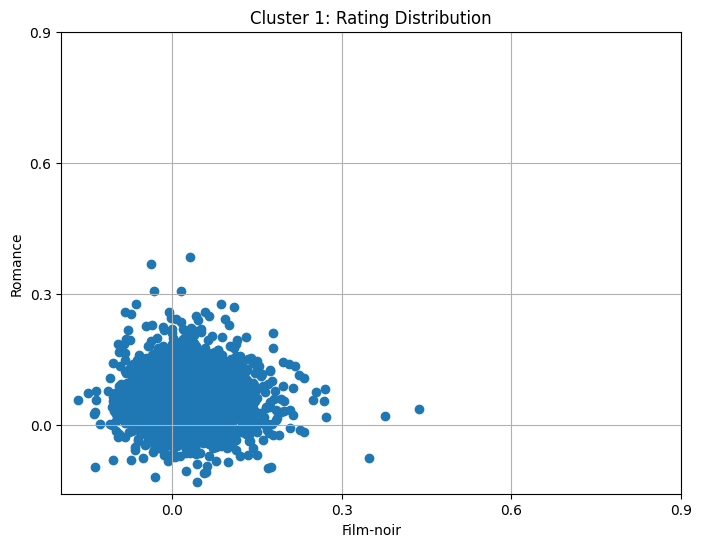

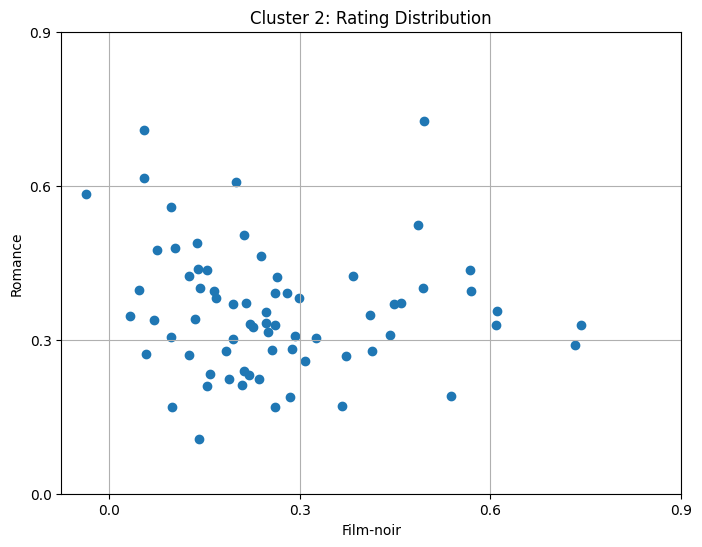

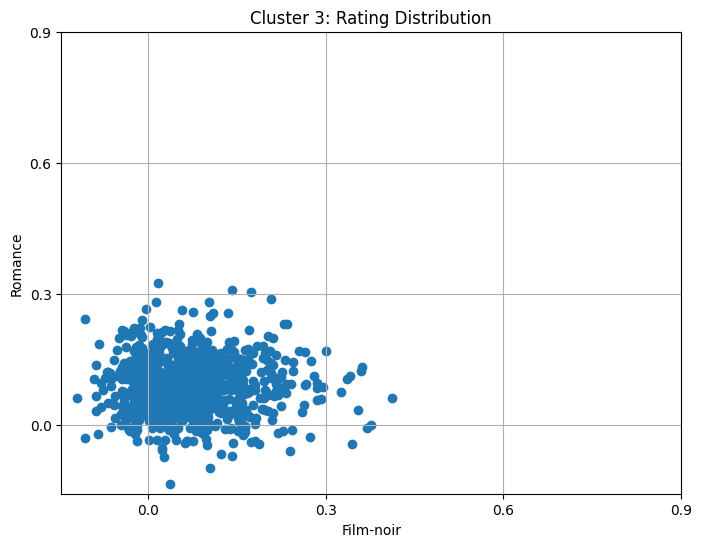

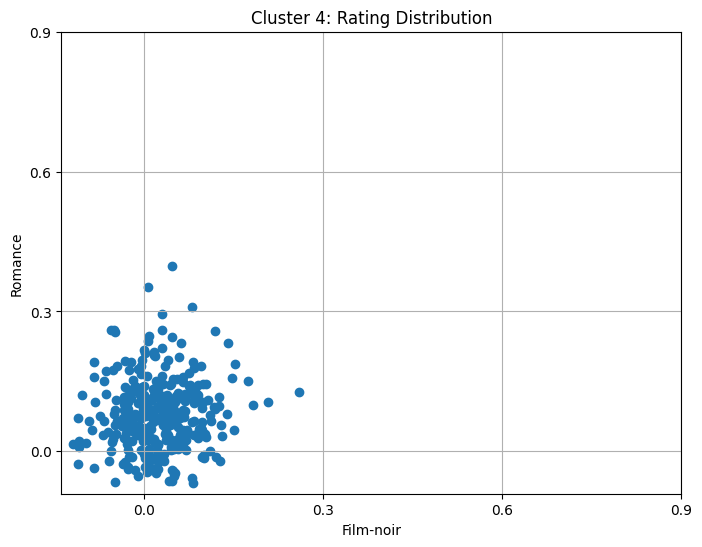

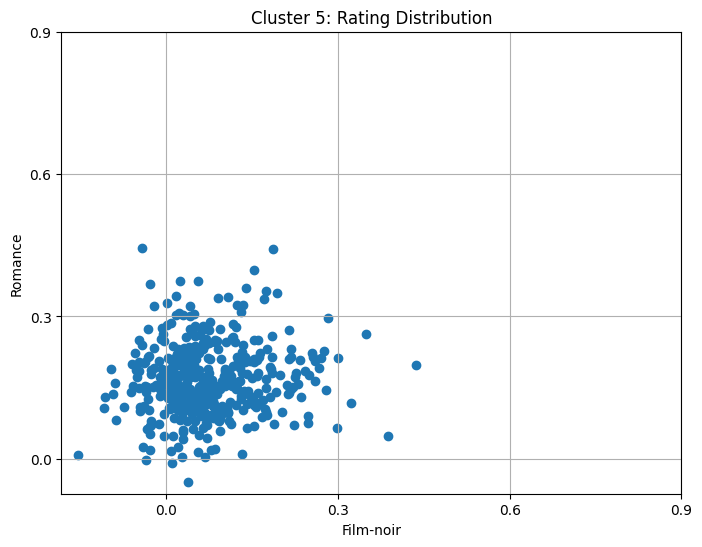

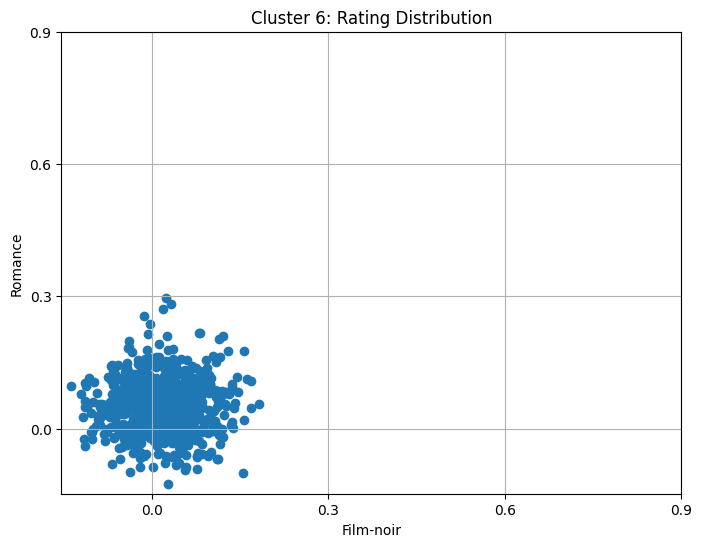

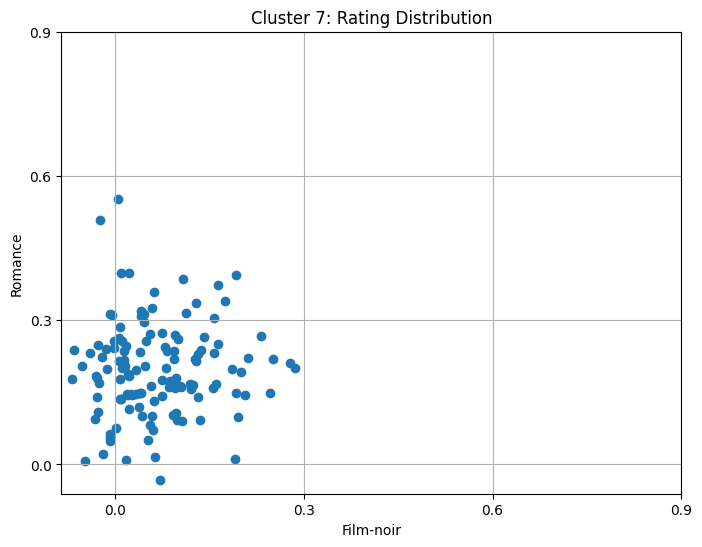

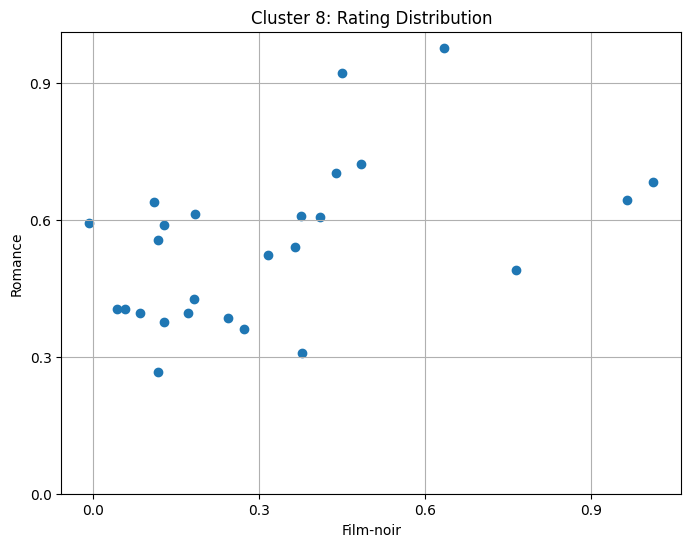

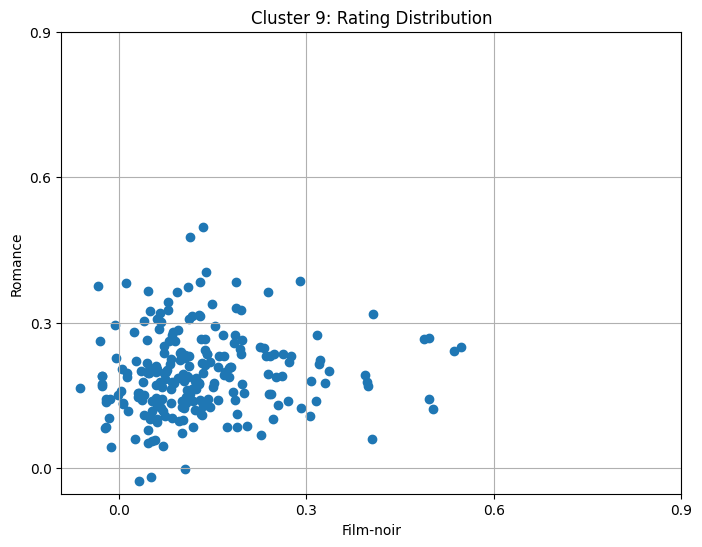

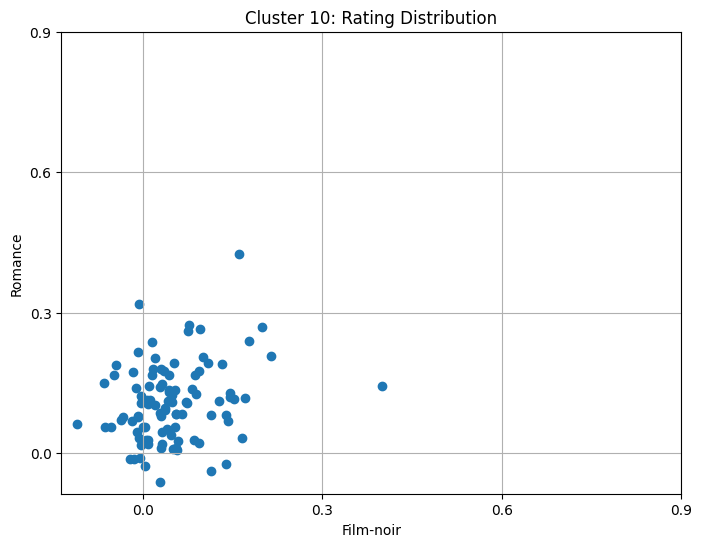

In [21]:
jitterX = np.random.normal(0, 0.05, size=user_item_matrix.shape[0])
jitterY = np.random.normal(0, 0.05, size=user_item_matrix.shape[0])

# Movies to plot
genre1 = 'g_Film-Noir'
genre2 = 'g_Romance'

for i in range(10):
	scatterData = total[total["cluster"] == i].dropna(subset=[genre1, genre2])

	# Add jitter
	jitterX = np.random.normal(0, 0.05, size=scatterData.shape[0])
	jitterY = np.random.normal(0, 0.05, size=scatterData.shape[0])

	# Plot
	plt.figure(figsize=(8, 6))
	scatter = plt.scatter(
		scatterData[genre1] + jitterX,
		scatterData[genre2] + jitterY
			)
	plt.xlabel(genre1.split('_')[1].capitalize())
	plt.ylabel(genre2.split('_')[1].capitalize())
	plt.title(f'Cluster {i+1}: Rating Distribution')
	plt.xticks(np.arange(0, 1.1, 0.3))
	plt.yticks(np.arange(0, 1.1, 0.3))
	plt.grid(True)
	plt.show()

In [22]:
from tqdm import tqdm

# Extract only numeric genre columns for KNN evaluation
genre_cols = [col for col in total.columns if col.startswith('g_')]
knnData = total[genre_cols + ['userId']].copy()  # Keep userId for reference

results_g = []

# Total iterations for progress bar
total_iterations = len(range(2, 10)) * len(range(1, 21))
pbar = tqdm(total=total_iterations, desc="Genre-based KMeans + KNN Evaluation")

best_results_g = {}  # Track best result per cluster count

for c in range(2, 10):
    cluster_results = []
    
    # Run KMeans once per cluster count (only on genre features)
    kmeans = KMeans(n_clusters=c, random_state=42, n_init=10, max_iter=300)
    clustering_features = knnData[genre_cols]
    knnData['cluster'] = kmeans.fit_predict(clustering_features)
    
    X = knnData[genre_cols]  # Only genre features for prediction
    y = knnData['cluster']                
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    for k in range(1, 21):
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        results_g.append({"clusters": c, "k": k, "acc": acc})
        cluster_results.append((k, acc))
        
        pbar.update(1)
    
    # Find best K for this cluster count
    best_k, best_acc = max(cluster_results, key=lambda x: x[1])
    best_results_g[c] = (best_k, best_acc)
    
    # Print summary for this cluster count
    print(f"Clusters: {c} | Best K: {best_k} | Best Accuracy: {best_acc:.6f}")

pbar.close()

# Overall summary
print("\n" + "="*60)
print("SUMMARY - Best Genre-based Results by Cluster Count:")
print("="*60)
for clusters, (k, acc) in best_results_g.items():
    print(f"{clusters:2d} clusters | K={k:2d} | Accuracy: {acc:.6f}")

# Find overall best
overall_best_g = max(best_results_g.items(), key=lambda x: x[1][1])
print(f"\nOverall Best: {overall_best_g[0]} clusters, K={overall_best_g[1][0]}, Accuracy: {overall_best_g[1][1]:.6f}")

Genre-based KMeans + KNN Evaluation:  14%|█▍        | 23/160 [00:01<00:06, 21.41it/s]

Clusters: 2 | Best K: 7 | Best Accuracy: 0.985000


Genre-based KMeans + KNN Evaluation:  26%|██▌       | 41/160 [00:01<00:05, 20.92it/s]

Clusters: 3 | Best K: 5 | Best Accuracy: 0.981000


Genre-based KMeans + KNN Evaluation:  39%|███▉      | 62/160 [00:02<00:04, 20.86it/s]

...

Clusters: 7 | Best K: 14 | Best Accuracy: 0.949000


Genre-based KMeans + KNN Evaluation:  89%|████████▉ | 143/160 [00:06<00:00, 18.68it/s]

Clusters: 8 | Best K: 7 | Best Accuracy: 0.934000


Genre-based KMeans + KNN Evaluation: 100%|██████████| 160/160 [00:07<00:00, 21.73it/s]

Clusters: 9 | Best K: 8 | Best Accuracy: 0.931000

SUMMARY - Best Genre-based Results by Cluster Count:
 2 clusters | K= 7 | Accuracy: 0.985000
 3 clusters | K= 5 | Accuracy: 0.981000
 4 clusters | K=17 | Accuracy: 0.963000
 5 clusters | K=11 | Accuracy: 0.949000
 6 clusters | K=11 | Accuracy: 0.941000
 7 clusters | K=14 | Accuracy: 0.949000
 8 clusters | K= 7 | Accuracy: 0.934000
 9 clusters | K= 8 | Accuracy: 0.931000

Overall Best: 2 clusters, K=7, Accuracy: 0.985000


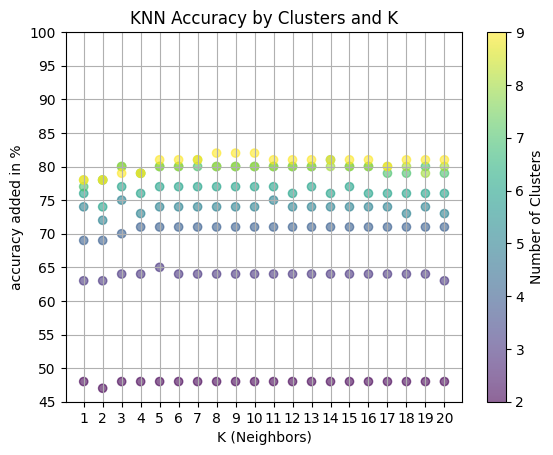

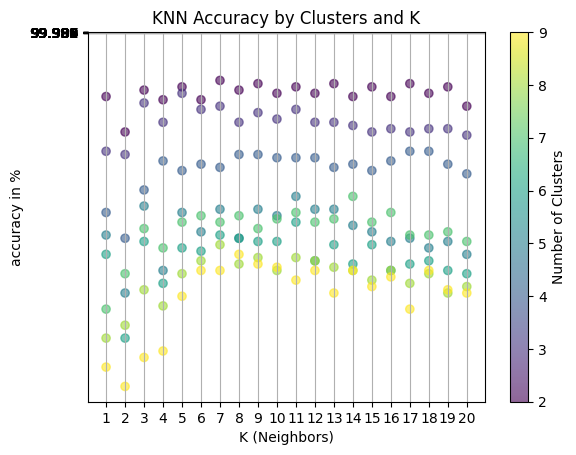

In [23]:
results_data_g = pd.DataFrame(results_g)
results_data_g["weightAcc"] =  results_data_g["acc"] - (1/results_data_g["clusters"])

plt.scatter(results_data_g['k'],results_data_g['weightAcc'].round(2)*100, c=results_data_g['clusters'], cmap='viridis', alpha=0.6)
plt.colorbar(label='Number of Clusters')
plt.xlabel('K (Neighbors)')
plt.ylabel('accuracy added in %')
plt.yticks(np.arange(45, 101, 5))
plt.xticks(np.arange(1, 21, 1))
plt.title('KNN Accuracy by Clusters and K')

plt.grid(True)
plt.show()

plt.scatter(results_data_g['k'],results_data_g['acc']*100, c=results_data_g['clusters'], cmap='viridis', alpha=0.6)
plt.colorbar(label='Number of Clusters')
plt.xlabel('K (Neighbors)')
plt.ylabel('accuracy in %')
plt.yticks(np.arange(99.980, 100, 0.001))
plt.xticks(np.arange(1, 21, 1))
plt.title('KNN Accuracy by Clusters and K')

plt.grid(True)
plt.show()

In [24]:
results_data_g[results_data_g["weightAcc"] == results_data_g["weightAcc"].max()]

,clusters,k,acc,weightAcc
147,9,8,0.931,0.819889


In [25]:
# Calculate RMSE and MAE for KMeans clustering evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

print("="*60)
print("CLUSTERING EVALUATION METRICS")
print("="*60)

# For movie rating-based clustering
print("\n1. MOVIE RATING-BASED CLUSTERING:")
print("-" * 40)

# Use the best configuration from previous results
best_movie_config = results_data[results_data["acc"] == results_data["acc"].max()].iloc[0]
best_clusters = int(best_movie_config["clusters"])
best_k = int(best_movie_config["k"])

print(f"Best Configuration: {best_clusters} clusters, K={best_k}")
print(f"Classification Accuracy: {best_movie_config['acc']:.4f}")

# Calculate RMSE and MAE for movie-based clustering
# Reconstruct the model with best parameters
data = user_item_matrix.copy()
data = data.drop(columns=['cluster'])

kmeans = KMeans(n_clusters=best_clusters, random_state=42, n_init=10, max_iter=300)
cluster_labels = kmeans.fit_predict(data)

# Calculate cluster centroids and distances
centroids = kmeans.cluster_centers_
distances = []
for i, point in enumerate(data.values):
    cluster_id = cluster_labels[i]
    centroid = centroids[cluster_id]
    # Calculate Euclidean distance to centroid
    distances.append(np.linalg.norm(point - centroid))

# Calculate RMSE and MAE
rmse_movie = np.sqrt(np.mean(np.array(distances)**2))
mae_movie = np.mean(distances)

print(f"RMSE (distance to centroid): {rmse_movie:.4f}")
print(f"MAE (distance to centroid): {mae_movie:.4f}")
print(f"Inertia (within-cluster sum of squares): {kmeans.inertia_:.2f}")

# For genre-based clustering
print("\n2. GENRE-BASED CLUSTERING:")
print("-" * 40)

# Use the best configuration from genre results
best_genre_config = results_data_g[results_data_g["weightAcc"] == results_data_g["weightAcc"].max()].iloc[0]
best_clusters_g = int(best_genre_config["clusters"])
best_k_g = int(best_genre_config["k"])

print(f"Best Configuration: {best_clusters_g} clusters, K={best_k_g}")
print(f"Classification Accuracy: {best_genre_config['acc']:.6f}")

# Calculate RMSE and MAE for genre-based clustering
genre_cols = [col for col in total.columns if col.startswith('g_')]
genre_data = total[genre_cols].copy()

kmeans_g = KMeans(n_clusters=best_clusters_g, random_state=42, n_init=10, max_iter=300)
cluster_labels_g = kmeans_g.fit_predict(genre_data)

# Calculate cluster centroids and distances
centroids_g = kmeans_g.cluster_centers_
distances_g = []
for i, point in enumerate(genre_data.values):
    cluster_id = cluster_labels_g[i]
    centroid = centroids_g[cluster_id]
    distances_g.append(np.linalg.norm(point - centroid))

# Calculate RMSE and MAE
rmse_genre = np.sqrt(np.mean(np.array(distances_g)**2))
mae_genre = np.mean(distances_g)

print(f"RMSE (distance to centroid): {rmse_genre:.6f}")
print(f"MAE (distance to centroid): {mae_genre:.6f}")
print(f"Inertia (within-cluster sum of squares): {kmeans_g.inertia_:.2f}")

# Comparison
print("\n3. COMPARISON:")
print("-" * 40)
print(f"Movie-based clustering - RMSE: {rmse_movie:.4f}, MAE: {mae_movie:.4f}")
print(f"Genre-based clustering - RMSE: {rmse_genre:.6f}, MAE: {mae_genre:.6f}")
print(f"\nGenre-based clustering achieves {(rmse_movie/rmse_genre):.1f}x lower RMSE")
print(f"Genre-based clustering achieves {(mae_movie/mae_genre):.1f}x lower MAE")

print("\n" + "="*60)

CLUSTERING EVALUATION METRICS

1. MOVIE RATING-BASED CLUSTERING:
----------------------------------------
Best Configuration: 2 clusters, K=2
Classification Accuracy: 0.9030
RMSE (distance to centroid): 68.0066
MAE (distance to centroid): 65.6374
Inertia (within-cluster sum of squares): 23124511.76

2. GENRE-BASED CLUSTERING:
----------------------------------------
Best Configuration: 9 clusters, K=8
Classification Accuracy: 0.931000
RMSE (distance to centroid): 0.222976
MAE (distance to centroid): 0.188013
Inertia (within-cluster sum of squares): 248.59

3. COMPARISON:
----------------------------------------
Movie-based clustering - RMSE: 68.0066, MAE: 65.6374
Genre-based clustering - RMSE: 0.222976, MAE: 0.188013

Genre-based clustering achieves 305.0x lower RMSE
Genre-based clustering achieves 349.1x lower MAE

